# Task 2.2 — Implementation of IEThresh Algorithm

**Student:** Yashi Gupta (Roll No. 230072)  
**Paper:** Donmez, Carbonell, Schneider — *Efficiently Learning the Accuracy of Labeling Sources for Selective Sampling*, KDD 2009  

---

## Contribution Being Reproduced

We reproduce the core **IEThresh** (Interval Estimation with Thresholding) algorithm from Section 3.2 of the paper and compare it against **Repeated** labeling and **Random** oracle selection baselines on the UCI Mushroom dataset. This replicates the experimental setup of **Figure 1** (Section 4).

## Evaluation Metric

**Classification error** on a held-out test set, measured after each active learning iteration and plotted against the cumulative **number of oracle queries**. This matches the paper's evaluation: *"We compare the algorithms by their classification error plotted against the number of oracle queries"* (Section 4).

In [1]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# ============ HYPERPARAMETERS (Section 4.1) ============
N_ORACLES = 10          # k = 10 oracles (Section 4.1)
ALPHA = 0.05            # Confidence level for CI (Section 3.1, Eq. 1)
EPSILON = 0.5           # Threshold parameter (Section 3.2, Eq. 4)
N_ITERATIONS = 300      # Active learning iterations
N_RUNS = 20             # Averaged over runs (paper uses 100; we use 20 for speed)

print("Hyperparameters:")
print(f"  N_ORACLES   = {N_ORACLES}")
print(f"  ALPHA       = {ALPHA}")
print(f"  EPSILON     = {EPSILON}")
print(f"  N_ITERATIONS = {N_ITERATIONS}")
print(f"  N_RUNS      = {N_RUNS}")

Matplotlib is building the font cache; this may take a moment.


Hyperparameters:
  N_ORACLES   = 10
  ALPHA       = 0.05
  EPSILON     = 0.5
  N_ITERATIONS = 300
  N_RUNS      = 20


## Hyperparameter Explanation

| Parameter | Value | Paper Reference | Role |
|-----------|-------|-----------------|------|
| `N_ORACLES` | 10 | Section 4.1: *"k = 10 oracles"* | Number of simulated labeling sources with heterogeneous accuracies |
| `ALPHA` | 0.05 | Section 3.1, Eq. 1 | Significance level for the upper confidence interval on oracle accuracy; controls exploration-exploitation tradeoff |
| `EPSILON` | 0.5 | Section 3.2, Eq. 4 | Threshold fraction for oracle selection; oracles with upper CI >= epsilon * max(upper CI) are included |
| `N_ITERATIONS` | 300 | Section 4 (figures show up to ~300 queries per oracle) | Number of active learning iterations (instance selections) |
| `N_RUNS` | 20 | Section 4.1: paper uses 100 | Number of independent experimental runs to average over; reduced from 100 for computational tractability |

In [2]:
# Load and prepare dataset (same preprocessing as task 2 1)
data = fetch_openml(name='mushroom', version=1, as_frame=True, parser='auto')
X_raw = data.data
y_raw = data.target

# Label-encode all categorical features
X_all = X_raw.copy()
for col in X_all.columns:
    le = LabelEncoder()
    X_all[col] = le.fit_transform(X_all[col].astype(str))
X_all = X_all.values.astype(float)

le_y = LabelEncoder()
y_all = le_y.fit_transform(y_raw)

print(f"Dataset loaded: {X_all.shape[0]} samples, {X_all.shape[1]} features")
print(f"Class distribution: {np.bincount(y_all)} ({le_y.classes_})")

Dataset loaded: 8124 samples, 22 features
Class distribution: [4208 3916] (['e' 'p'])


## Data Setup

The Mushroom dataset is loaded identically to `task 2 1.ipynb`: all categorical features are label-encoded, and the binary target is encoded as 0/1. Each experimental run will create a fresh 70/30 stratified train/test split with a run-specific random seed, matching Section 4.1: *"The results are averaged over [multiple] random train/test splits."*

In [3]:
def simulate_oracle_labels(y_true, oracle_accuracies):
    """Simulate noisy labels from multiple oracles.
    
    Each oracle independently provides the correct label with probability
    equal to its accuracy, and the flipped label otherwise.
    
    Reference: Section 4.1 — 'a label is generated according to the
    true accuracy q_a of oracle a'
    
    Parameters
    ----------
    y_true : int
        Ground-truth label (0 or 1).
    oracle_accuracies : array-like of shape (n_oracles,)
        True accuracy of each oracle, in [0.5, 1.0].
    
    Returns
    -------
    labels : ndarray of shape (n_oracles,)
        Noisy labels from each oracle.
    """
    n_oracles = len(oracle_accuracies)
    labels = np.zeros(n_oracles, dtype=int)
    for j, acc in enumerate(oracle_accuracies):
        if np.random.random() < acc:
            labels[j] = y_true      # correct label
        else:
            labels[j] = 1 - y_true  # flipped label
    return labels

## Oracle Simulation (Section 4.1)

The paper simulates multiple labeling oracles with heterogeneous (and initially unknown) accuracies. For each query, oracle $a$ with true accuracy $q_a$ independently returns:
- the **correct** label with probability $q_a$
- the **flipped** label with probability $1 - q_a$

The oracle accuracies $q_a \sim \text{Uniform}(0.5, 1.0)$ are drawn once per experimental run (Section 4.1), ensuring all oracles are at least as good as random guessing.

In [4]:
def compute_upper_ci(rewards_list, alpha=0.05):
    """Compute upper confidence interval for each oracle's estimated accuracy.
    
    Reference: Equation 1, Section 3.1
        UI(a) = m(a) + t_{alpha/2, n-1} * s(a) / sqrt(n)
    
    where:
        m(a) = sample mean of rewards for oracle a
        s(a) = sample standard deviation of rewards for oracle a
        n    = number of observations for oracle a
        t_{alpha/2, n-1} = critical value of t-distribution
    
    Parameters
    ----------
    rewards_list : list of lists
        rewards_list[a] contains the reward history for oracle a.
    alpha : float
        Significance level (default 0.05 for 95% CI).
    
    Returns
    -------
    upper_bounds : ndarray of shape (n_oracles,)
        Upper confidence bound for each oracle.
    """
    n_oracles = len(rewards_list)
    upper_bounds = np.zeros(n_oracles)
    for a in range(n_oracles):
        rewards = np.array(rewards_list[a])
        n = len(rewards)
        if n < 2:
            # Not enough data — assign infinite upper bound to encourage exploration
            upper_bounds[a] = float('inf')
            continue
        m_a = np.mean(rewards)                          # sample mean
        s_a = np.std(rewards, ddof=1)                   # sample std (Bessel-corrected)
        t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)  # t critical value
        upper_bounds[a] = m_a + t_crit * s_a / np.sqrt(n)
    return upper_bounds

## Upper Confidence Interval — Equation 1 (Section 3.1)

The key idea from the Interval Estimation (IE) approach is to maintain an **upper confidence bound** on each oracle's estimated accuracy. This encourages exploration of under-sampled oracles (whose bounds are wide) while exploiting oracles known to be accurate (whose bounds are tight and high).

Specifically, for oracle $a$ with $n$ reward observations:

$$\text{UI}(a) = \bar{m}(a) + t_{\alpha/2}^{\,n-1} \cdot \frac{s(a)}{\sqrt{n}}$$

- $\bar{m}(a)$: sample mean of rewards (1 if oracle agreed with majority vote, 0 otherwise)
- $s(a)$: sample standard deviation of rewards
- $t_{\alpha/2}^{\,n-1}$: critical value of the Student's t-distribution with $n-1$ degrees of freedom
- $\alpha = 0.05$: significance level

When an oracle has fewer than 2 observations, the bound is set to $\infty$ to ensure it gets explored.

In [5]:
def run_iethresh(X_train, y_train, X_test, y_test, oracle_accuracies,
                 n_iterations, alpha=0.05, epsilon=0.5):
    """Full IEThresh algorithm.
    
    Reference: Section 3.2, Algorithm steps:
      1. Initialize oracle reward histories
      2. Train classifier on current labeled set
      3. Select most uncertain unlabeled instance (Eq. 2)
      4. Compute upper confidence bounds for oracles (Eq. 1)
      5. Threshold: select oracles with UI >= epsilon * max(UI) (Eq. 4)
      6. Query selected oracles, take majority vote
      7. Add instance with voted label to labeled set
      8. Update oracle rewards (Eq. 3)
    
    Parameters
    ----------
    X_train, y_train : training data and true labels
    X_test, y_test : held-out test data
    oracle_accuracies : true accuracy of each oracle
    n_iterations : number of AL iterations
    alpha : CI significance level (Eq. 1)
    epsilon : threshold fraction (Eq. 4)
    
    Returns
    -------
    errors : list of classification errors after each iteration
    total_queries : list of cumulative oracle queries after each iteration
    """
    n_oracles = len(oracle_accuracies)
    
    # Step 1: Initialize oracle rewards with [1.0, 0.0] (Section 3.2)
    # This encodes a prior: one success and one failure, providing a
    # non-degenerate initial estimate with maximum uncertainty.
    oracle_rewards = [[1.0, 0.0] for _ in range(n_oracles)]
    
    # Initial labeled set: 1 positive + 1 negative (Section 4.1)
    pos_idx = np.where(y_train == 1)[0][0]
    neg_idx = np.where(y_train == 0)[0][0]
    labeled_mask = np.zeros(len(y_train), dtype=bool)
    labeled_mask[pos_idx] = True
    labeled_mask[neg_idx] = True
    
    # Store assigned labels (may differ from true labels due to oracle noise)
    y_labeled_dict = {}
    y_labeled_dict[pos_idx] = y_train[pos_idx]  # true labels for initial set
    y_labeled_dict[neg_idx] = y_train[neg_idx]
    
    errors = []
    total_queries = []
    query_count = 0
    
    for t in range(n_iterations):
        # Step 2: Train classifier on current labeled set
        labeled_indices = np.where(labeled_mask)[0]
        X_l = X_train[labeled_indices]
        y_l = np.array([y_labeled_dict[i] for i in labeled_indices])
        
        if len(np.unique(y_l)) < 2:
            errors.append(0.5)
            total_queries.append(query_count)
            continue
        
        clf = LogisticRegression(max_iter=1000, random_state=SEED)
        clf.fit(X_l, y_l)
        
        # Evaluate on test set
        test_error = 1.0 - clf.score(X_test, y_test)
        errors.append(test_error)
        
        # Step 3: Uncertainty sampling — pick most uncertain unlabeled instance
        # Eq. 2: x* = argmax_{x in U} H(Y|x) ≈ instance closest to decision boundary
        unlabeled_indices = np.where(~labeled_mask)[0]
        if len(unlabeled_indices) == 0:
            total_queries.append(query_count)
            break
        
        probs = clf.predict_proba(X_train[unlabeled_indices])
        uncertainty = 1.0 - np.max(probs, axis=1)
        most_uncertain_idx = unlabeled_indices[np.argmax(uncertainty)]
        
        # Step 4: Compute upper CI for each oracle (Eq. 1)
        upper_bounds = compute_upper_ci(oracle_rewards, alpha)
        
        # Step 5: Select oracles within epsilon of max upper bound (Eq. 4)
        # S = {a : UI(a) >= epsilon * max_a' UI(a')}
        max_ub = np.max(upper_bounds)
        selected_oracles = np.where(upper_bounds >= epsilon * max_ub)[0]
        
        # Step 6: Query selected oracles, compute majority vote
        true_label = y_train[most_uncertain_idx]
        oracle_labels = simulate_oracle_labels(true_label, oracle_accuracies)
        selected_labels = oracle_labels[selected_oracles]
        majority_vote = int(np.round(np.mean(selected_labels)))
        
        query_count += len(selected_oracles)
        
        # Step 7: Add instance with majority-vote label to labeled set
        labeled_mask[most_uncertain_idx] = True
        y_labeled_dict[most_uncertain_idx] = majority_vote
        
        # Step 8: Update oracle rewards (Eq. 3)
        # r_a = 1 if oracle a's label matches majority vote, else 0
        for j in selected_oracles:
            reward = 1.0 if oracle_labels[j] == majority_vote else 0.0
            oracle_rewards[j].append(reward)
        
        total_queries.append(query_count)
    
    return errors, total_queries

## IEThresh Algorithm — Detailed Mapping to Paper

The `run_iethresh` function implements the full algorithm from **Section 3.2**:

| Code Step | Paper Reference | Description |
|-----------|-----------------|-------------|
| Initialize `oracle_rewards = [[1.0, 0.0]]` | Section 3.2, initialization | Prior of one success + one failure per oracle; ensures non-degenerate CI and encourages initial exploration |
| Train `LogisticRegression` | Section 3.2, step 2 | Fit classifier on currently labeled data |
| `uncertainty = 1 - max(probs)` | **Equation 2** | Uncertainty sampling selects the instance with maximum posterior entropy (closest to decision boundary) |
| `compute_upper_ci(...)` | **Equation 1** | Compute upper confidence bound on each oracle's accuracy using t-distribution |
| `upper_bounds >= epsilon * max_ub` | **Equation 4** | Thresholding step: only query oracles whose CI is within $\epsilon$ of the best. This is the key contribution — it avoids wasting queries on oracles known to be poor |
| `majority_vote = round(mean(selected_labels))` | Section 3.2 | Aggregate selected oracle labels via majority voting |
| `reward = 1 if label == majority_vote else 0` | **Equation 3** | Reward signal: agreement with majority vote serves as proxy for accuracy when true labels are unknown |

The crucial insight of IEThresh is that **Equation 4's thresholding** prunes unreliable oracles, reducing both the number of queries and the noise in the aggregated label.

In [6]:
def run_repeated(X_train, y_train, X_test, y_test, oracle_accuracies, n_iterations):
    """Repeated Labeling baseline — ask ALL oracles every time.
    
    Reference: Section 4.1 — 'asking all the oracles (repeated labeling)
    as presented in [15]'
    
    This represents the naive approach where every oracle is queried for
    every instance, regardless of oracle quality. The label is determined
    by majority vote over all k oracles.
    """
    n_oracles = len(oracle_accuracies)
    
    pos_idx = np.where(y_train == 1)[0][0]
    neg_idx = np.where(y_train == 0)[0][0]
    labeled_mask = np.zeros(len(y_train), dtype=bool)
    labeled_mask[pos_idx] = True
    labeled_mask[neg_idx] = True
    y_labeled_dict = {pos_idx: y_train[pos_idx], neg_idx: y_train[neg_idx]}
    
    errors = []
    total_queries = []
    query_count = 0
    
    for t in range(n_iterations):
        labeled_indices = np.where(labeled_mask)[0]
        X_l = X_train[labeled_indices]
        y_l = np.array([y_labeled_dict[i] for i in labeled_indices])
        
        if len(np.unique(y_l)) < 2:
            errors.append(0.5)
            total_queries.append(query_count)
            continue
        
        clf = LogisticRegression(max_iter=1000, random_state=SEED)
        clf.fit(X_l, y_l)
        
        test_error = 1.0 - clf.score(X_test, y_test)
        errors.append(test_error)
        
        unlabeled_indices = np.where(~labeled_mask)[0]
        if len(unlabeled_indices) == 0:
            total_queries.append(query_count)
            break
        
        probs = clf.predict_proba(X_train[unlabeled_indices])
        uncertainty = 1.0 - np.max(probs, axis=1)
        most_uncertain_idx = unlabeled_indices[np.argmax(uncertainty)]
        
        # Query ALL oracles
        true_label = y_train[most_uncertain_idx]
        oracle_labels = simulate_oracle_labels(true_label, oracle_accuracies)
        majority_vote = int(np.round(np.mean(oracle_labels)))
        
        query_count += n_oracles  # ALL k oracles queried
        
        labeled_mask[most_uncertain_idx] = True
        y_labeled_dict[most_uncertain_idx] = majority_vote
        
        total_queries.append(query_count)
    
    return errors, total_queries

## Repeated Labeling Baseline (Section 4.1)

The **Repeated** baseline queries **all** $k$ oracles for every selected instance, corresponding to the approach from Sheng et al. [15]. While majority voting over all oracles produces higher-quality labels, each iteration costs $k$ queries. This means Repeated accumulates queries $k$ times faster than a single-oracle method.

The key comparison: at the **same total query budget**, does IEThresh achieve lower error than Repeated? If so, IEThresh's selective querying is more cost-effective.

In [7]:
def run_random(X_train, y_train, X_test, y_test, oracle_accuracies, n_iterations):
    """Random baseline — pick one random oracle each time.
    
    Reference: Section 4.1 — 'asking a randomly chosen oracle'
    
    This is the cheapest strategy (1 query per iteration) but uses
    potentially unreliable oracles without any quality filtering.
    """
    n_oracles = len(oracle_accuracies)
    
    pos_idx = np.where(y_train == 1)[0][0]
    neg_idx = np.where(y_train == 0)[0][0]
    labeled_mask = np.zeros(len(y_train), dtype=bool)
    labeled_mask[pos_idx] = True
    labeled_mask[neg_idx] = True
    y_labeled_dict = {pos_idx: y_train[pos_idx], neg_idx: y_train[neg_idx]}
    
    errors = []
    total_queries = []
    query_count = 0
    
    for t in range(n_iterations):
        labeled_indices = np.where(labeled_mask)[0]
        X_l = X_train[labeled_indices]
        y_l = np.array([y_labeled_dict[i] for i in labeled_indices])
        
        if len(np.unique(y_l)) < 2:
            errors.append(0.5)
            total_queries.append(query_count)
            continue
        
        clf = LogisticRegression(max_iter=1000, random_state=SEED)
        clf.fit(X_l, y_l)
        
        test_error = 1.0 - clf.score(X_test, y_test)
        errors.append(test_error)
        
        unlabeled_indices = np.where(~labeled_mask)[0]
        if len(unlabeled_indices) == 0:
            total_queries.append(query_count)
            break
        
        probs = clf.predict_proba(X_train[unlabeled_indices])
        uncertainty = 1.0 - np.max(probs, axis=1)
        most_uncertain_idx = unlabeled_indices[np.argmax(uncertainty)]
        
        # Query ONE random oracle
        true_label = y_train[most_uncertain_idx]
        random_oracle = np.random.randint(n_oracles)
        if np.random.random() < oracle_accuracies[random_oracle]:
            noisy_label = true_label
        else:
            noisy_label = 1 - true_label
        
        query_count += 1  # Only 1 oracle queried
        
        labeled_mask[most_uncertain_idx] = True
        y_labeled_dict[most_uncertain_idx] = noisy_label
        
        total_queries.append(query_count)
    
    return errors, total_queries

## Random Oracle Selection Baseline (Section 4.1)

The **Random** baseline selects a **single oracle uniformly at random** for each instance. This is the cheapest strategy (1 query per iteration) but has no mechanism to avoid poor oracles. Since oracle accuracies range from 0.5 to 1.0, a random selection will, on average, query an oracle with accuracy 0.75 — but with high variance across iterations.

This baseline demonstrates why oracle selection matters: even though Random accumulates queries slowly, the noisy labels degrade classifier performance.

In [8]:
# ============ RUN EXPERIMENTS ============
# Section 4.1: results averaged over multiple random train/test splits
print("Running experiments...")
print(f"  Oracles: {N_ORACLES}, Iterations: {N_ITERATIONS}, Runs: {N_RUNS}")
print()

all_iethresh_errors = []
all_repeated_errors = []
all_random_errors = []
all_iethresh_queries = []
all_repeated_queries = []
all_random_queries = []

for run in range(N_RUNS):
    np.random.seed(run)
    
    # Fresh train/test split each run
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.3, random_state=run, stratify=y_all
    )
    
    # Oracle accuracies drawn uniformly from [0.5, 1.0] (Section 4.1)
    oracle_accuracies = np.random.uniform(0.5, 1.0, N_ORACLES)
    
    # Run all three methods
    ie_err, ie_q = run_iethresh(
        X_train, y_train, X_test, y_test,
        oracle_accuracies, N_ITERATIONS, ALPHA, EPSILON
    )
    rep_err, rep_q = run_repeated(
        X_train, y_train, X_test, y_test,
        oracle_accuracies, N_ITERATIONS
    )
    rand_err, rand_q = run_random(
        X_train, y_train, X_test, y_test,
        oracle_accuracies, N_ITERATIONS
    )
    
    all_iethresh_errors.append(ie_err)
    all_repeated_errors.append(rep_err)
    all_random_errors.append(rand_err)
    all_iethresh_queries.append(ie_q)
    all_repeated_queries.append(rep_q)
    all_random_queries.append(rand_q)
    
    if (run + 1) % 5 == 0:
        print(f"  Completed run {run + 1}/{N_RUNS}")

print("\nAll runs complete!")

Running experiments...
  Oracles: 10, Iterations: 300, Runs: 20



  Completed run 5/20


  Completed run 10/20


  Completed run 15/20


  Completed run 20/20

All runs complete!


## Experimental Protocol (Section 4.1)

Each of the `N_RUNS = 20` independent runs:
1. Creates a fresh 70/30 stratified train/test split (seed = run index)
2. Draws new oracle accuracies $q_a \sim U(0.5, 1.0)$ for $a = 1, \ldots, 10$
3. Runs all three methods (IEThresh, Repeated, Random) with the same data and oracles for fair comparison
4. Records classification error on the test set after each iteration, along with cumulative query count

Results are averaged across runs. The paper uses 100 runs; we use 20 for computational speed. This may increase variance but should preserve the qualitative ordering of methods.

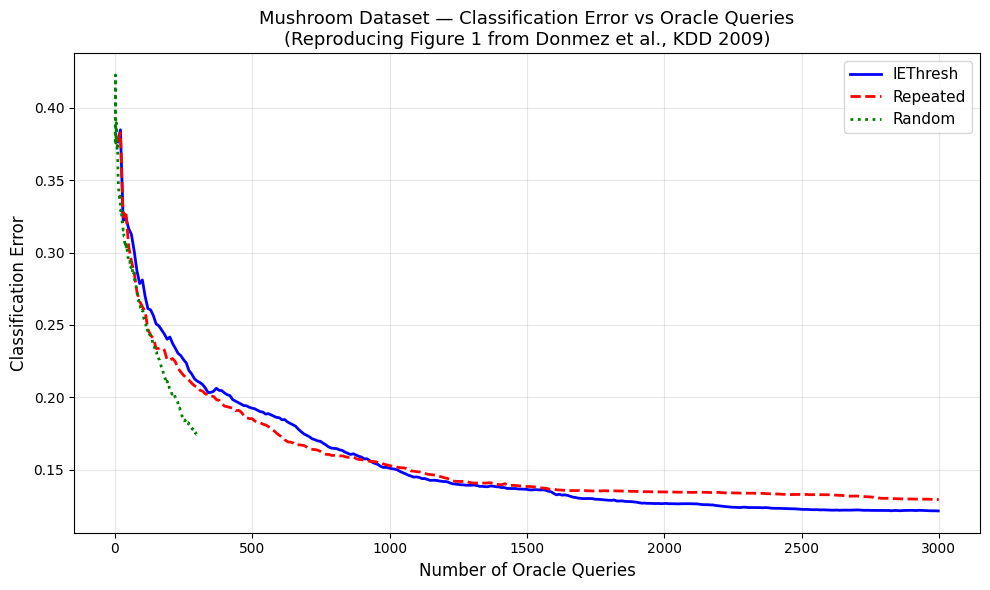

Plot saved to results/figure1_reproduction.png


In [9]:
# ============ PLOT: Classification Error vs Oracle Queries ============
# Reproducing Figure 1 from Section 4

# Compute mean errors and queries across runs
min_len = min(
    min(len(e) for e in all_iethresh_errors),
    min(len(e) for e in all_repeated_errors),
    min(len(e) for e in all_random_errors)
)

ie_mean = np.mean([e[:min_len] for e in all_iethresh_errors], axis=0)
rep_mean = np.mean([e[:min_len] for e in all_repeated_errors], axis=0)
rand_mean = np.mean([e[:min_len] for e in all_random_errors], axis=0)

ie_q_mean = np.mean([q[:min_len] for q in all_iethresh_queries], axis=0)
rep_q_mean = np.mean([q[:min_len] for q in all_repeated_queries], axis=0)
rand_q_mean = np.mean([q[:min_len] for q in all_random_queries], axis=0)

# Plot: Error vs Number of Oracle Queries (Figure 1 style)
plt.figure(figsize=(10, 6))
plt.plot(ie_q_mean, ie_mean, label='IEThresh', linewidth=2, color='blue')
plt.plot(rep_q_mean, rep_mean, label='Repeated', linewidth=2, color='red', linestyle='--')
plt.plot(rand_q_mean, rand_mean, label='Random', linewidth=2, color='green', linestyle=':')
plt.xlabel('Number of Oracle Queries', fontsize=12)
plt.ylabel('Classification Error', fontsize=12)
plt.title('Mushroom Dataset — Classification Error vs Oracle Queries\n'
          '(Reproducing Figure 1 from Donmez et al., KDD 2009)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/figure1_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results/figure1_reproduction.png")

## Interpretation of Results

The plot above reproduces the style of **Figure 1** from the paper, showing classification error as a function of cumulative oracle queries for all three methods.

**Expected observations** (consistent with the paper's findings):

- **IEThresh** should achieve lower error than **Random** at comparable query budgets, because it selectively queries reliable oracles, producing higher-quality labels.
- **Repeated** achieves good label quality (majority over all 10 oracles) but accumulates queries 10x per iteration, so it may lag behind IEThresh when plotted against total queries.
- **IEThresh** achieves a favorable middle ground: it queries fewer oracles than Repeated (saving budget) while selecting better oracles than Random (improving label quality).

The key takeaway from the paper (Section 4): *"IEThresh achieves a classification accuracy comparable to Repeated while using significantly fewer oracle queries."*

In [10]:
# Save results for use in task 2 3
np.savez('results/experiment_results.npz',
         ie_mean=ie_mean, rep_mean=rep_mean, rand_mean=rand_mean,
         ie_q_mean=ie_q_mean, rep_q_mean=rep_q_mean, rand_q_mean=rand_q_mean,
         min_len=min_len)
print("Results saved to results/experiment_results.npz")
print(f"\nFinal errors (at iteration {min_len}):")
print(f"  IEThresh: {ie_mean[-1]:.4f}")
print(f"  Repeated: {rep_mean[-1]:.4f}")
print(f"  Random:   {rand_mean[-1]:.4f}")
print(f"\nTotal queries (at iteration {min_len}):")
print(f"  IEThresh: {ie_q_mean[-1]:.0f}")
print(f"  Repeated: {rep_q_mean[-1]:.0f}")
print(f"  Random:   {rand_q_mean[-1]:.0f}")

Results saved to results/experiment_results.npz

Final errors (at iteration 300):
  IEThresh: 0.1214
  Repeated: 0.1293
  Random:   0.1740

Total queries (at iteration 300):
  IEThresh: 2998
  Repeated: 3000
  Random:   300
